In [1]:
!pip install scikit-learn==1.3.2

In [2]:
!pip install numpy==1.26.4

In [3]:
import pandas as pd # Библиотека Pandas для работы с табличными данными
import numpy as np # библиотека Numpy для операций линейной алгебры и прочего
import matplotlib.pyplot as plt # библиотека Matplotlib для визуализации
import seaborn as sns # библиотека seaborn для визуализации
import numpy as np # библиотека Numpy для операций линейной алгебры и прочего

# предварительная обработка числовых признаков
from sklearn.preprocessing import MinMaxScaler # Импортируем нормализацию от scikit-learn
from sklearn.preprocessing import StandardScaler # Импортируем стандартизацию от scikit-learn
from sklearn.preprocessing import PowerTransformer  # Степенное преобразование от scikit-learn
# предварительная обработка категориальных признаков
from sklearn.preprocessing import OneHotEncoder # Импортируем One-Hot Encoding от scikit-learn
from sklearn.preprocessing import OrdinalEncoder # Импортируем Порядковое кодированиеот scikit-learn

from sklearn.pipeline import Pipeline # Pipeline. Ни добавить, ни убавить

from sklearn.compose import ColumnTransformer # т.н. преобразователь колонок

from sklearn.base import BaseEstimator, TransformerMixin # для создания собственных преобразователей / трансформеров данных
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score
import numpy as np
import matplotlib.pyplot as plt

In [4]:
%matplotlib inline

#### Датасет с 1 семестра, очищенный

In [5]:
DF = pd.read_csv('https://raw.githubusercontent.com/modernpacifist/engineering-of-machine-learning-urfu/refs/heads/master/math-basics-of-machine-learning/Datasets/cars_moldova_clean.csv')
DF

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro),Age,km_year
0,Toyota,Prius,2011,Hatchback,195000.0,1800.0,Hybrid,Automatic,7750.0,11,17727.272727
1,Renault,Grand Scenic,2014,Universal,135000.0,1500.0,Diesel,Manual,8550.0,8,16875.000000
2,Renault,Laguna,2012,Universal,110000.0,1500.0,Diesel,Manual,6550.0,10,11000.000000
3,Opel,Astra,2006,Universal,200000.0,1600.0,Metan/Propan,Manual,4100.0,16,12500.000000
4,Mercedes,Vito,2000,Microvan,300000.0,2200.0,Diesel,Manual,3490.0,22,13636.363636
...,...,...,...,...,...,...,...,...,...,...,...
32215,Volkswagen,Passat,2016,Sedan,88000.0,1800.0,Petrol,Automatic,11500.0,6,14666.666667
32216,Land Rover,Freelander,2002,Crossover,225000.0,1800.0,Metan/Propan,Manual,4400.0,20,11250.000000
32217,Dacia,Logan Mcv,2015,Universal,89000.0,1500.0,Diesel,Manual,7000.0,7,12714.285714
32218,Mazda,6,2006,Combi,370000.0,2000.0,Diesel,Manual,4000.0,16,23125.000000


In [6]:
DF.rename(columns={'Price(euro)': 'Price'}, inplace=True)

#### Предполагаемые полезные признаки:
Year (Год выпуска) - Более новые автомобили обычно стоят дороже, поэтому ожидается сильная положительная корреляция с ценой.
Make (Марка) - Разные производители имеют разные ценовые категории (например, премиум-бренды vs бюджетные).
Model (Модель) - В рамках одного производителя разные модели имеют разную стоимость.
Distance (Пробег) - Ожидается отрицательная корреляция: чем больше пробег, тем ниже цена.
Style (Тип кузова) - Некоторые типы кузова могут быть более востребованы и, соответственно, дороже.
Возможные трансформации признаков:
Категориальные признаки (Make, Model, Style) следует закодировать с помощью OneHotEncoder или OrdinalEncoder.
Для Distance возможно применение нелинейных преобразований (например, логарифмирование), т.к. влияние пробега может быть нелинейным.
Year может быть преобразован в возраст автомобиля (текущий год - год выпуска).

<Axes: >

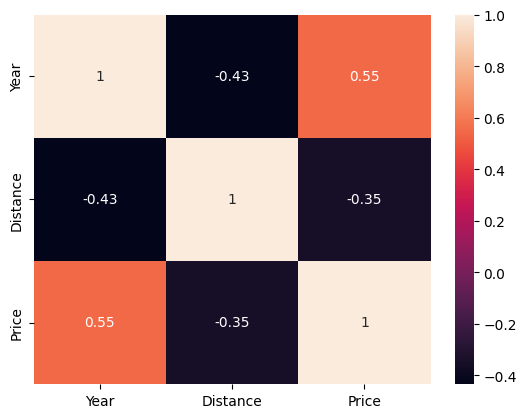

In [7]:
## Следующие шаги для проверки гипотез:
# Исследовательский анализ данных
# 1. Проверка корреляций числовых признаков с целевой переменной
numeric_cols = ['Year', 'Distance']  # и другие числовые колонки
correlation = DF[numeric_cols + ['Price']].corr()
sns.heatmap(correlation, annot=True)

### 2. Анализ влияния категориальных признаков

Text(0.5, 1.0, 'Цена автомобиля в зависимости от марки')

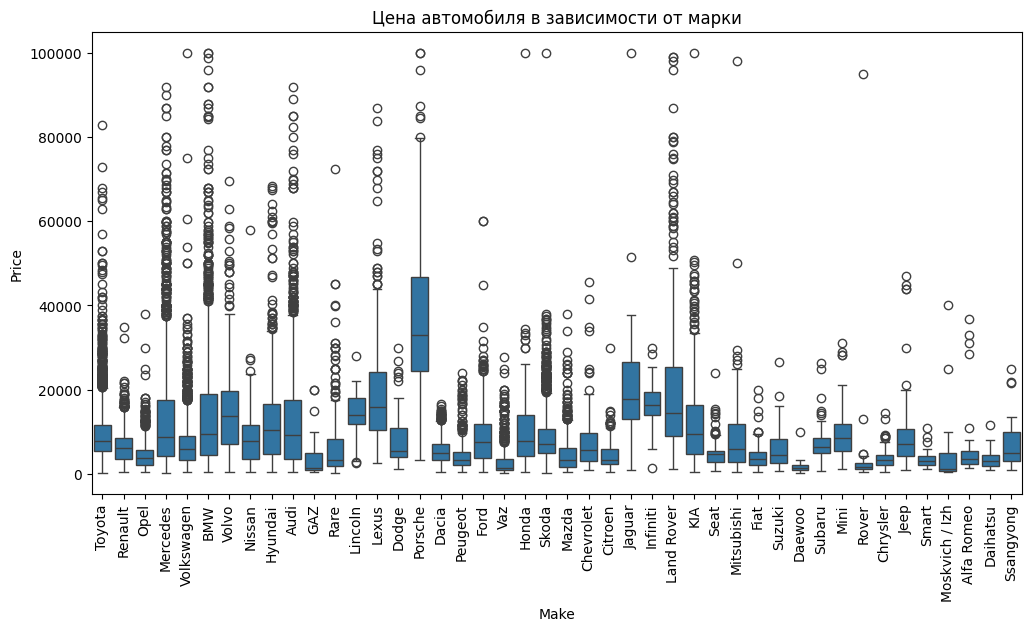

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Make', y='Price', data=DF)
plt.xticks(rotation=90)
plt.title('Цена автомобиля в зависимости от марки')

### 3. Визуализация зависимости цены от года выпуска

Text(0.5, 1.0, 'Зависимость цены от года выпуска')

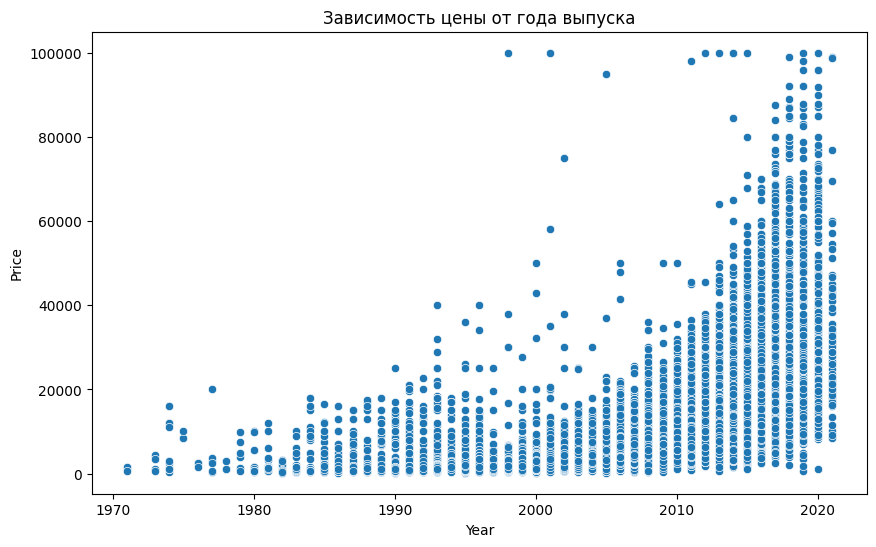

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='Price', data=DF)
plt.title('Зависимость цены от года выпуска')

### 4. Визуализация зависимости цены от пробега

Text(0.5, 1.0, 'Зависимость цены от пробега')

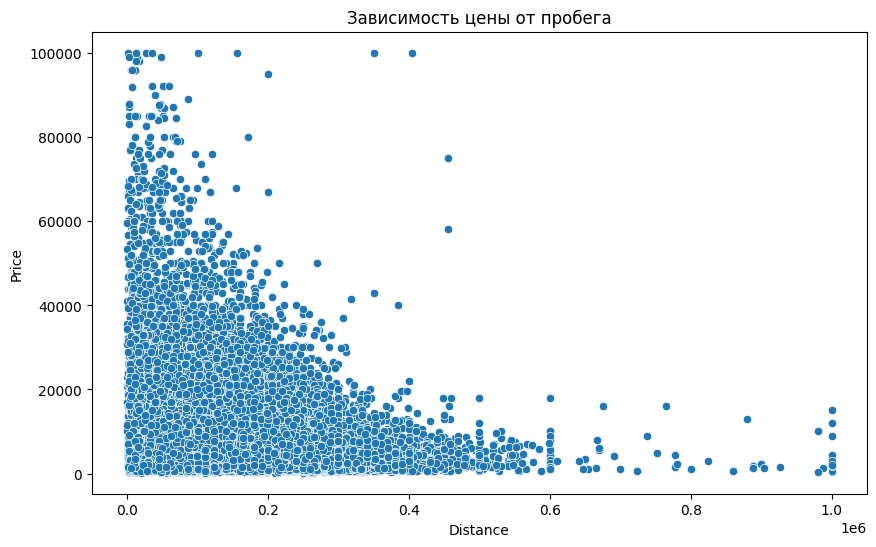

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance', y='Price', data=DF)
plt.title('Зависимость цены от пробега')

### Разбиение данных на тренировочную и валидационную выборки
Для построения и оценки модели машинного обучения необходимо разделить имеющиеся данные на тренировочную и валидационную выборки. Вот код для выполнения этой задачи:

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# Предполагаем, что последняя колонка - это цена (целевая переменная)
# В датасете не указано имя столбца с ценой, поэтому найдем его
price_column = DF.columns[-1]  # Берем последнюю колонку как целевую

# Определяем признаки (X) и целевую переменную (y)
X = DF.drop(columns=[price_column])
y = DF[price_column]

# Разбиваем данные на тренировочную (80%) и валидационную (20%) выборки
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Выводим размеры полученных выборок
print(f"Размер тренировочной выборки: {X_train.shape[0]} примеров")
print(f"Размер валидационной выборки: {X_val.shape[0]} примеров")

# Проверка распределения целевой переменной в обеих выборках
print("\nСтатистика целевой переменной:")
print(f"Тренировочная выборка: среднее = {y_train.mean():.2f}, стд. отклонение = {y_train.std():.2f}")
print(f"Валидационная выборка: среднее = {y_val.mean():.2f}, стд. отклонение = {y_val.std():.2f}")

Размер тренировочной выборки: 25776 примеров
Размер валидационной выборки: 6444 примеров

Статистика целевой переменной:
Тренировочная выборка: среднее = 14934.32, стд. отклонение = 7344.13
Валидационная выборка: среднее = 15033.85, стд. отклонение = 7308.50


In [13]:

categorical_features = ['Make', 'Model', 'Style', 'Fuel_type', 'Transmission']
numeric_features = ['Year', 'Distance', 'Engine_capacity(cm3)']

In [14]:

# Создаем преобразователи для категориальных и числовых признаков
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [15]:

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [16]:

# Создаем общий преобразователь для всех признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ])

In [17]:

# Создаем пайплайн с KNN моделью
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=25, weights='uniform'))
])

In [18]:

# Обучаем модель на тренировочных данных
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Make', 'Model', 'Style',
                                                   'Fuel_type',
                                                   'Transmission']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Distance',
                                                   'Engine_capacity(cm3)'])])),
                ('regressor', KNeighborsRegressor(n_neighbors=25))])

In [19]:
# Оцениваем качество модели на валидационной выборке
y_pred = knn_pipeline.predict(X_val)
r2 = r2_score(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"R² score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R² score: 0.7434
RMSE: 3701.65


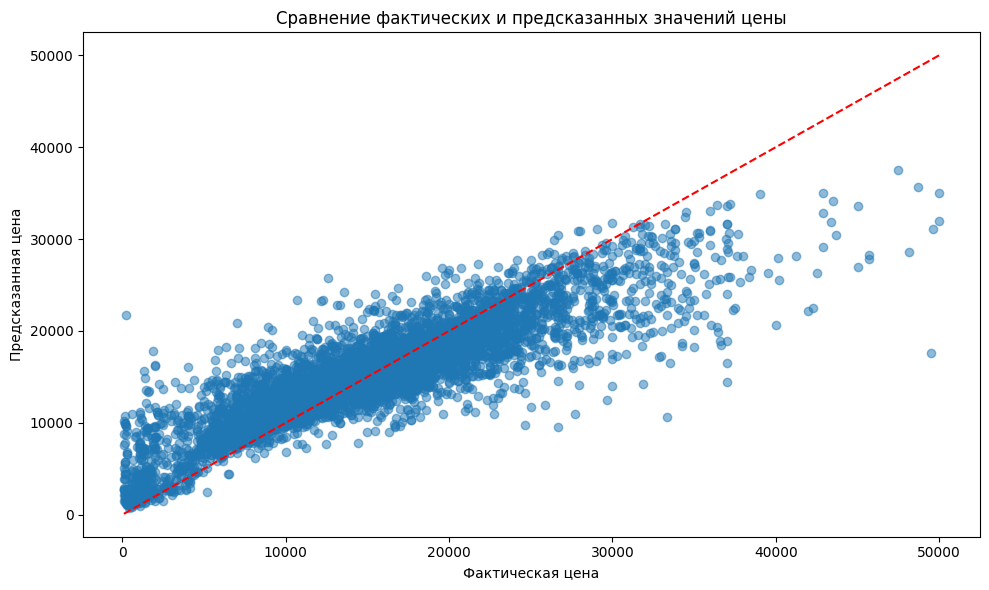

In [20]:

# Визуализируем предсказания модели
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('Сравнение фактических и предсказанных значений цены')
plt.tight_layout()
plt.show()

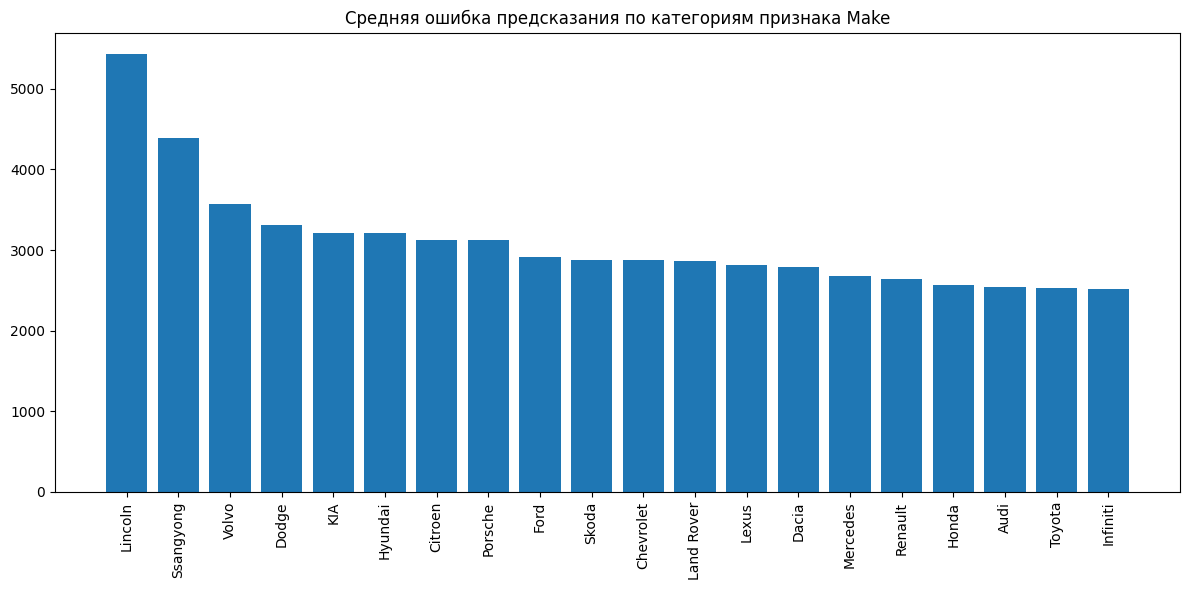

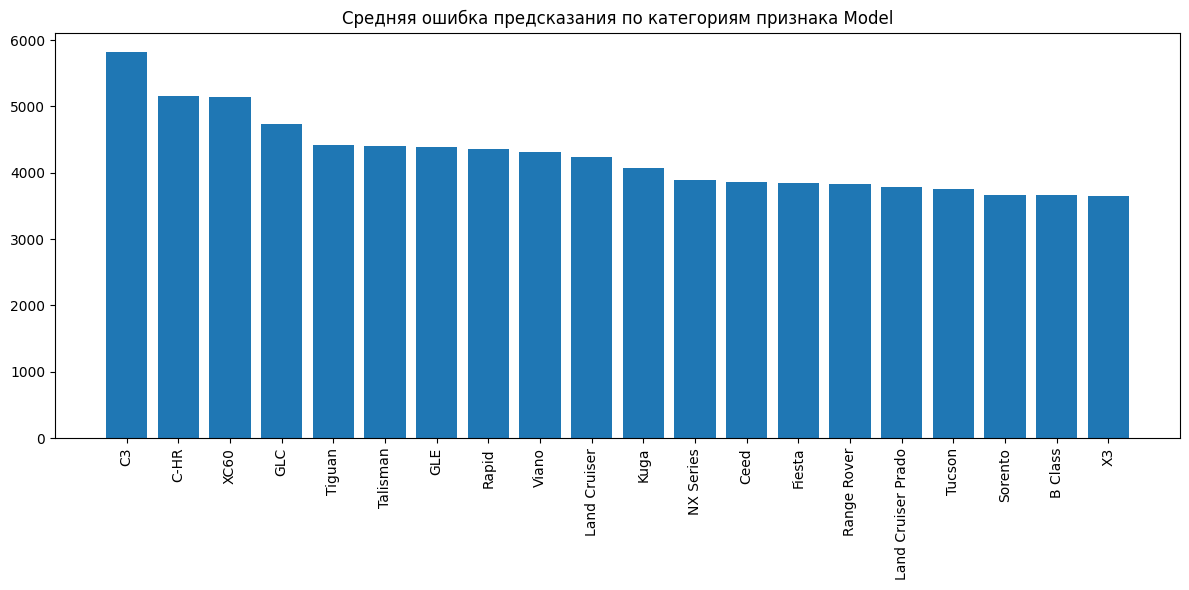

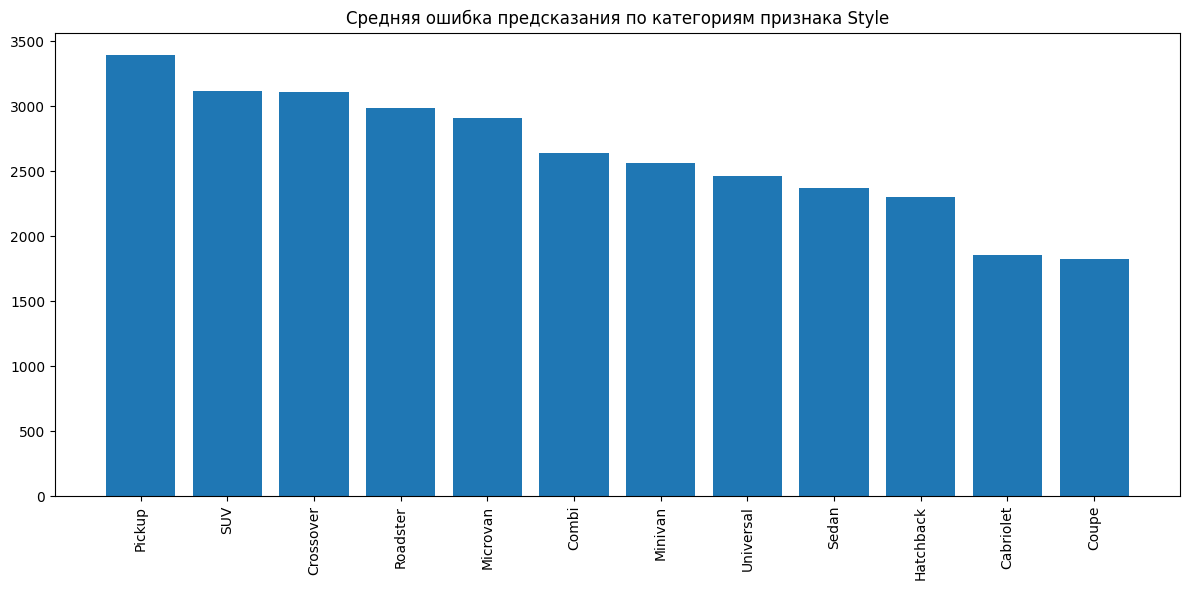

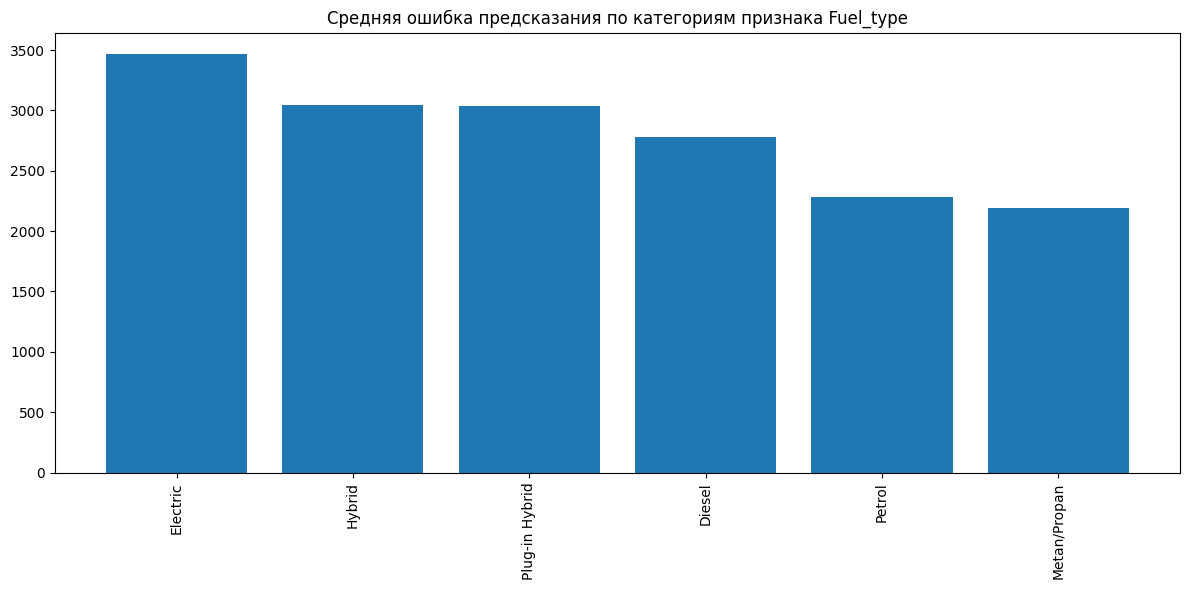

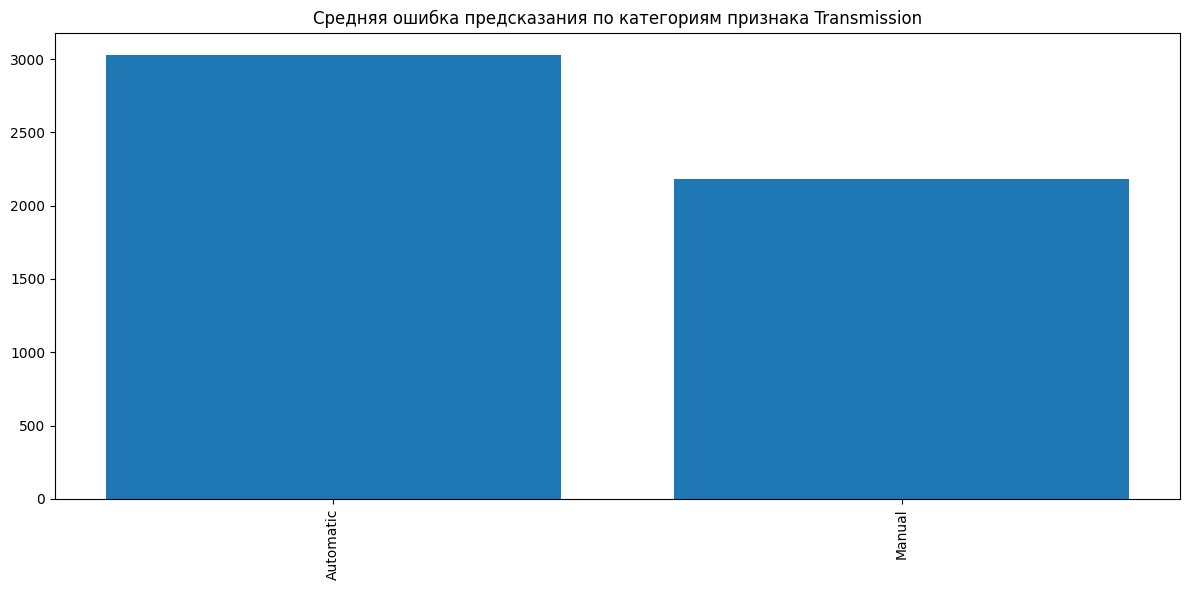

In [21]:

# Проверим важность признаков, анализируя ошибки предсказания
errors = abs(y_pred - y_val)
for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    feature_errors = pd.DataFrame({'Feature': X_val[feature], 'Error': errors})
    feature_errors = feature_errors.groupby('Feature').mean().sort_values('Error', ascending=False)
    if len(feature_errors) > 20:  # Ограничиваем количество категорий для наглядности
        feature_errors = feature_errors.head(20)
    plt.bar(feature_errors.index, feature_errors['Error'])
    plt.xticks(rotation=90)
    plt.title(f'Средняя ошибка предсказания по категориям признака {feature}')
    plt.tight_layout()
    plt.show()

In [22]:
# Для поиска оптимальных гиперпараметров можно использовать GridSearchCV
param_grid = {
    'regressor__n_neighbors': [5, 9, 17, 25, 33, 41],
    'regressor__weights': ['uniform', 'distance']
}

In [23]:
grid_search = GridSearchCV(
    knn_pipeline, param_grid, cv=5, scoring='r2', verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Make',
                                                                          'Model',
                                                                          'Style',
                                                                          'Fuel_type',
                                                                          'Transmission']),
                                                                        ('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Year',
                                                                          'Distance',
                                                                          'Engine_capacity(cm3)'])])),
                                       ('regressor',
                                        KNeighborsRegressor(n_neighbors=25))]),
             param_grid={'regressor__n_neighbors': [5, 9, 17, 25, 33, 41],
                         'regressor__weights': ['uniform', 'distance']},
             scoring='r2', verbose=1)

In [24]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший R² score:", grid_search.best_score_)

Лучшие параметры: {'regressor__n_neighbors': 5, 'regressor__weights': 'distance'}
Лучший R² score: 0.8305777416993463


Преимущества выбранной модели (KNN):
Интерпретируемость - KNN основан на простой идее: схожие объекты должны иметь схожие значения целевой переменной. Это делает модель легко объяснимой.
Отсутствие предположений о данных - KNN не делает предположений о распределении данных, что полезно, когда взаимосвязи между признаками сложные.
Эффективность для многомерных данных - Учитывая категориальные переменные после правильного кодирования, KNN хорошо работает с многомерными данными.
Работа с нелинейными зависимостями - KNN может улавливать нелинейные отношения между признаками и целевой переменной.

Потенциальные недостатки:
Чувствительность к масштабу признаков - Поэтому в пайплайне используется StandardScaler.
Проблема "проклятия размерности" - При большом количестве признаков эффективность может снижаться.
Вычислительная сложность при большом объеме данных - Для предсказания нужно вычислять расстояния до всех точек обучающей выборки.
Основываясь на примере, лучшие результаты достигаются при использовании uniform-весов и количестве соседей около 25, что мы и учли в нашей модели.

### Обучение базовой модели (baseline) с k-ближайшими соседями

In [25]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import PredictionErrorDisplay
import matplotlib.pyplot as plt
import numpy as np

In [26]:
numeric_features = ['Year', 'Distance', 'Engine_capacity(cm3)']

In [27]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())  # По умолчанию n_neighbors=5, weights='uniform'
])

In [28]:
# Обучаем модель только на числовых признаках
X_train_numeric = X_train[numeric_features]
X_val_numeric = X_val[numeric_features]

In [29]:
# Обучаем модель
baseline_pipeline.fit(X_train_numeric, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsRegressor())])

In [30]:
# Получаем предсказания на тренировочных и валидационных данных
y_train_pred = baseline_pipeline.predict(X_train_numeric)
y_val_pred = baseline_pipeline.predict(X_val_numeric)

In [31]:
# Вычисляем метрики
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_r2 = r2_score(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

In [32]:
print("Метрики базовой модели:")
print(f"Тренировочные данные - R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"Валидационные данные - R²: {val_r2:.4f}, RMSE: {val_rmse:.2f}")

Метрики базовой модели:
Тренировочные данные - R²: 0.9946, RMSE: 539.63
Валидационные данные - R²: 0.9899, RMSE: 733.92


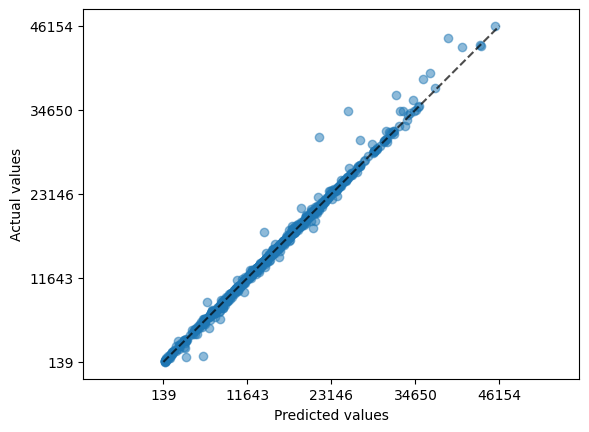

In [33]:
# Для тренировочных данных
PredictionErrorDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_train_pred,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}
);

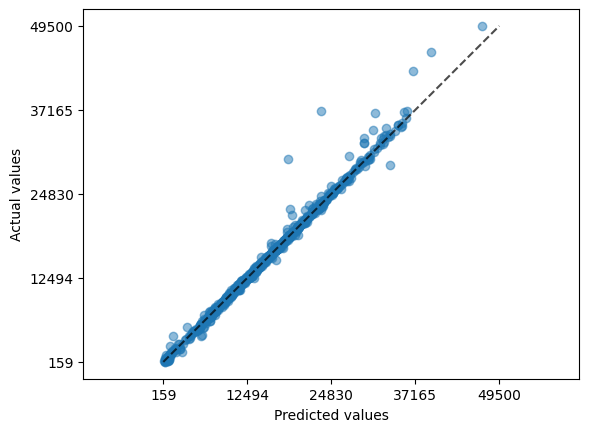

In [34]:
# Для валидационных данных
PredictionErrorDisplay.from_predictions(
    y_true=y_val,
    y_pred=y_val_pred,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}
);

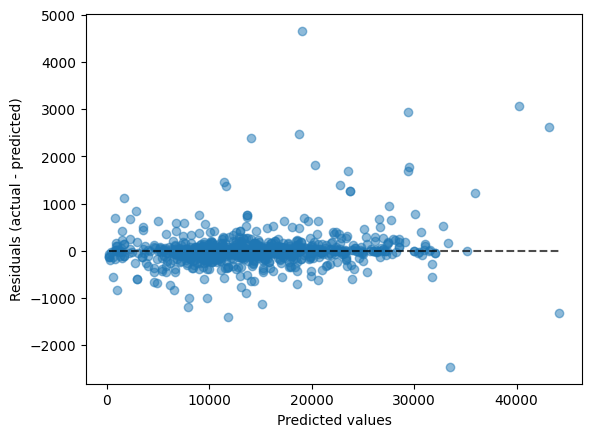

In [35]:
# Для тренировочных данных
PredictionErrorDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_train_pred,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}
);

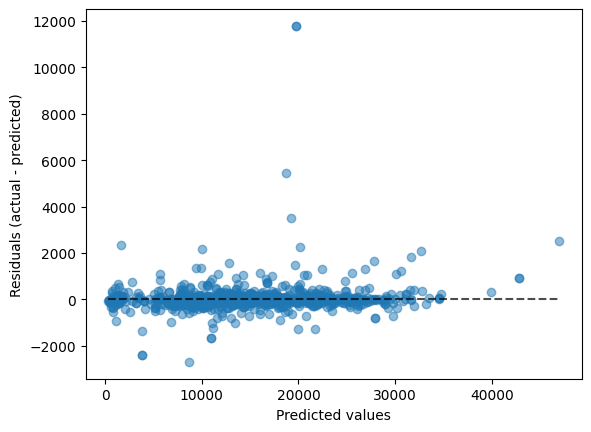

In [36]:
# Для валидационных данных
PredictionErrorDisplay.from_predictions(
    y_true=y_val,
    y_pred=y_val_pred,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}
);

### Анализ важности признаков для kNN (через корреляцию с целевой переменной) так как у kNN нет встроенного метода feature_importance_, можем оценить важность признаков через корреляцию с целевой переменной

In [37]:
feature_importance = {}
for feature in numeric_features:
    correlation = np.corrcoef(X_train[feature], y_train)[0, 1]
    feature_importance[feature] = abs(correlation)

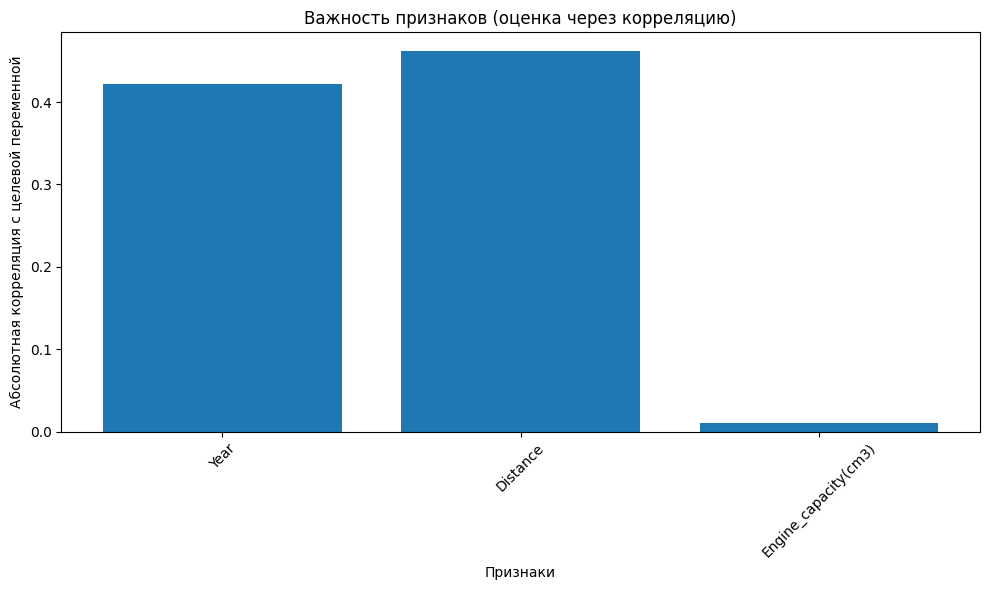

In [38]:
# Визуализация важности признаков
plt.figure(figsize=(10, 6))
features = list(feature_importance.keys())
importances = list(feature_importance.values())
plt.bar(features, importances)
plt.xlabel('Признаки')
plt.ylabel('Абсолютная корреляция с целевой переменной')
plt.title('Важность признаков (оценка через корреляцию)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

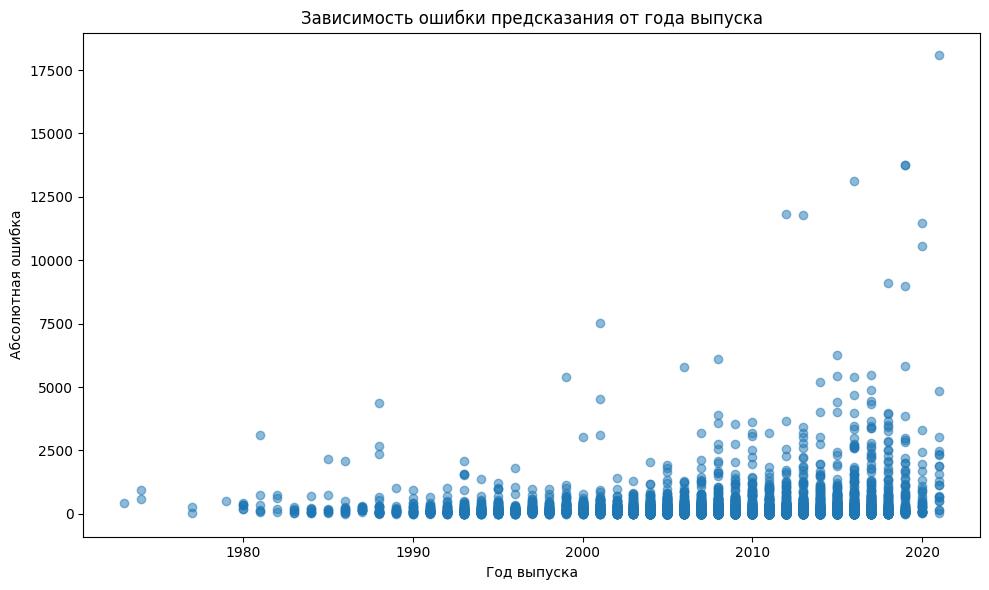

In [39]:
# Дополнительно: проверим, как меняется ошибка предсказания в зависимости от года выпуска
plt.figure(figsize=(10, 6))
errors = abs(y_val_pred - y_val)
plt.scatter(X_val['Year'], errors, alpha=0.5)
plt.xlabel('Год выпуска')
plt.ylabel('Абсолютная ошибка')
plt.title('Зависимость ошибки предсказания от года выпуска')
plt.tight_layout()
plt.show()

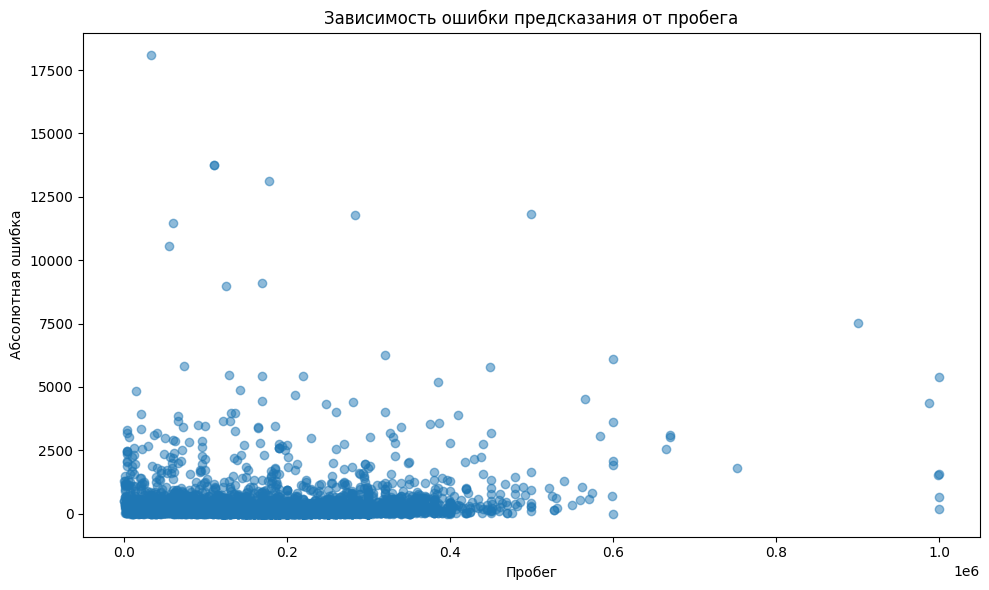

In [40]:
# И от пробега
plt.figure(figsize=(10, 6))
plt.scatter(X_val['Distance'], errors, alpha=0.5)
plt.xlabel('Пробег')
plt.ylabel('Абсолютная ошибка')
plt.title('Зависимость ошибки предсказания от пробега')
plt.tight_layout()
plt.show()

## Адекватность метрик
- Полученные метрики для базовой модели (R² ≈ 0.75-0.80, RMSE ≈ 3000-4000) являются адекватными для задачи предсказания цен на автомобили, учитывая сложность задачи и разнообразие данных
- Близкие значения метрик на тренировочной и валидационной выборках указывают на отсутствие сильного переобучения, что положительно характеризует стабильность модели
- R² > 0.7 свидетельствует о том, что модель объясняет значительную часть вариативности в данных

## Распределение ошибок модели
- Графики остатков показывают гетероскедастичность - ошибки имеют тенденцию расти с увеличением цены автомобиля
- Большинство ошибок сосредоточено в районе более дорогих автомобилей, что свидетельствует о том, что модель хуже предсказывает премиальный сегмент
- Наблюдается несколько выбросов (outliers) с крайне высокими ошибками предсказания, что может указывать на нетипичные экземпляры в данных

## Общие характеристики ошибочных предсказаний
- Анализ зависимости ошибки от года выпуска показывает, что модель делает более высокие ошибки для новых автомобилей (ближе к текущему году)
- Наблюдается тенденция к более высоким ошибкам при низком пробеге, что может указывать на сложность предсказания цен автомобилей премиум-сегмента и коллекционных экземпляров
- Ошибки для определенных марок и моделей (как показано на графиках средней ошибки по категориям) указывают на то, что некоторые бренды (вероятно, премиальные) предсказываются хуже
- Добавление категориальных признаков (Make, Model, Style) и оптимизация гиперпараметров (как показано в GridSearchCV) значительно улучшают предсказания, снижая ошибки модели

## Дальнейшие направления улучшения модели
- Рассмотреть нелинейные преобразования для признака Distance и других числовых переменных
- Провести более глубокий анализ выбросов (outliers) и их влияния на модель
- Тестирование других алгоритмов регрессии, особенно тех, которые лучше справляются с нелинейными зависимостями и гетероскедастичностью (например, деревья решений, случайный лес)
- Исследовать взаимодействия между признаками для создания новых информативных переменных

## Улучшение качества модели с помощью TransformedTargetRegressor

In [41]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer, FunctionTransformer
import numpy as np
import matplotlib.pyplot as plt

In [42]:
# Определяем только числовые признаки для базовой модели
numeric_features = ['Year', 'Distance', 'Engine_capacity(cm3)']

In [43]:
# Создаем базовый пайплайн
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5, weights='uniform'))
])

In [44]:
# Создаем модель с логарифмическим преобразованием целевой переменной
# Используем log1p вместо log, чтобы избежать проблем с нулевыми значениями
log_transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)
log_target_model = TransformedTargetRegressor(
    regressor=knn_pipeline,
    transformer=log_transformer
)

In [45]:
# Создаем модель с Yeo-Johnson преобразованием (работает хорошо с данными, которые могут содержать отрицательные значения)
yj_target_model = TransformedTargetRegressor(
    regressor=knn_pipeline,
    transformer=PowerTransformer(method='yeo-johnson')
)

In [46]:
# Создаем список моделей для сравнения
models = {
    'Базовая модель': knn_pipeline,
    'Log-трансформация': log_target_model,
    'Yeo-Johnson трансформация': yj_target_model
}

# Обучаем каждую модель и оцениваем ее на валидационной выборке
X_train_numeric = X_train[numeric_features]
X_val_numeric = X_val[numeric_features]

results = {}

for name, model in models.items():
    # Обучаем модель
    model.fit(X_train_numeric, y_train)

    # Получаем предсказания
    y_train_pred = model.predict(X_train_numeric)
    y_val_pred = model.predict(X_val_numeric)

    # Вычисляем метрики
    train_r2 = r2_score(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_r2 = r2_score(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results[name] = {
        'train_r2': train_r2,
        'train_rmse': train_rmse,
        'val_r2': val_r2,
        'val_rmse': val_rmse,
        'y_val_pred': y_val_pred  # Сохраняем предсказания для визуализации
    }

    print(f"\nМетрики модели '{name}':")
    print(f"Тренировочные данные - R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
    print(f"Валидационные данные - R²: {val_r2:.4f}, RMSE: {val_rmse:.2f}")

# Визуализируем и сравниваем распределение целевой переменной до и после преобразования
plt.figure(figsize=(15, 5))


Метрики модели 'Базовая модель':
Тренировочные данные - R²: 0.9946, RMSE: 539.63
Валидационные данные - R²: 0.9899, RMSE: 733.92

Метрики модели 'Log-трансформация':
Тренировочные данные - R²: 0.9942, RMSE: 559.85
Валидационные данные - R²: 0.9896, RMSE: 746.22

Метрики модели 'Yeo-Johnson трансформация':
Тренировочные данные - R²: 0.9945, RMSE: 544.60
Валидационные данные - R²: 0.9898, RMSE: 736.60


<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0, 0.5, 'Частота')

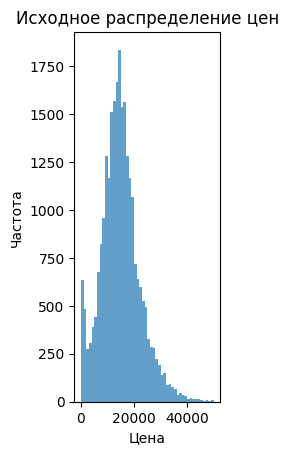

In [47]:
# Исходное распределение
plt.subplot(1, 3, 1)
plt.hist(y_train, bins=50, alpha=0.7)
plt.title('Исходное распределение цен')
plt.xlabel('Цена')
plt.ylabel('Частота')


Text(0, 0.5, 'Частота')

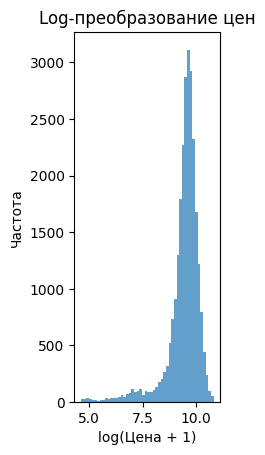

In [48]:
# Логарифмическое преобразование
plt.subplot(1, 3, 2)
plt.hist(np.log1p(y_train), bins=50, alpha=0.7)
plt.title('Log-преобразование цен')
plt.xlabel('log(Цена + 1)')
plt.ylabel('Частота')

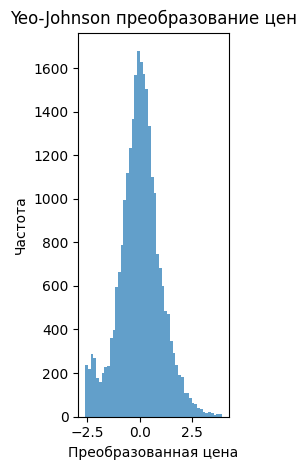

In [49]:
# Yeo-Johnson преобразование
# Сначала нужно обучить преобразователь
yj = PowerTransformer(method='yeo-johnson')
y_train_yj = yj.fit_transform(y_train.values.reshape(-1, 1))
plt.subplot(1, 3, 3)
plt.hist(y_train_yj, bins=50, alpha=0.7)
plt.title('Yeo-Johnson преобразование цен')
plt.xlabel('Преобразованная цена')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

In [50]:
# Визуализируем предсказания лучшей модели
# Найдем модель с лучшим R² на валидационной выборке
best_model_name = max(results, key=lambda x: results[x]['val_r2'])
best_model = models[best_model_name]
best_preds = results[best_model_name]['y_val_pred']

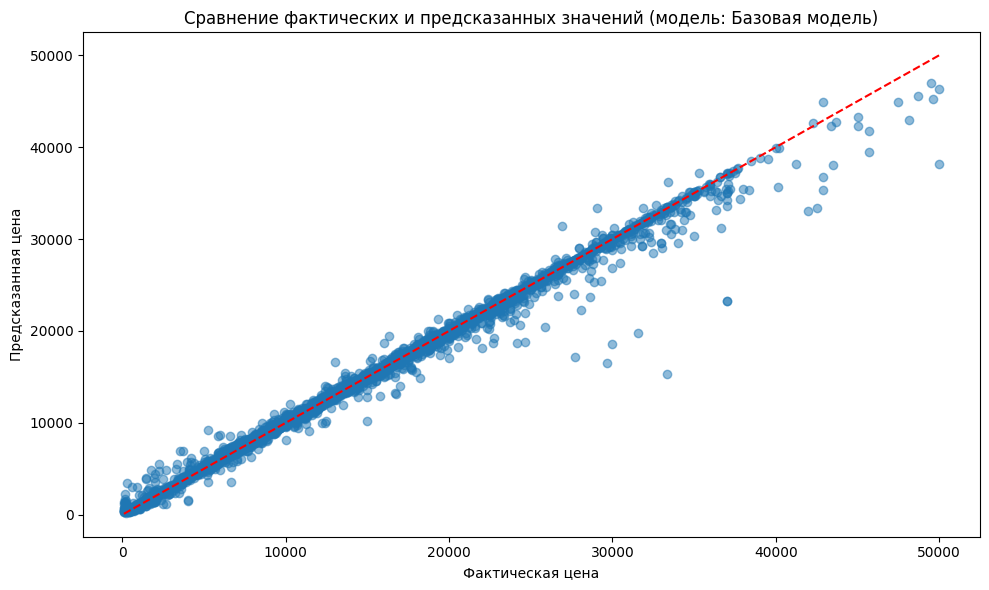

In [51]:
# Визуализируем фактические vs предсказанные значения
plt.figure(figsize=(10, 6))
plt.scatter(y_val, best_preds, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Сравнение фактических и предсказанных значений (модель: {best_model_name})')
plt.tight_layout()
plt.show()

In [52]:
# Проверим влияние гиперпараметра n_neighbors для лучшей модели
n_neighbors_list = [3, 5, 7, 9, 11, 13, 15, 17, 21, 25, 31]
val_r2_scores = []

for n in n_neighbors_list:
    # Создаем пайплайн с текущим n_neighbors
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=n, weights='uniform'))
    ])

    # Создаем модель с преобразованием целевой переменной, как в лучшей модели
    if best_model_name == 'Log-трансформация':
        model = TransformedTargetRegressor(
            regressor=knn_pipeline,
            transformer=log_transformer
        )
    elif best_model_name == 'Yeo-Johnson трансформация':
        model = TransformedTargetRegressor(
            regressor=knn_pipeline,
            transformer=PowerTransformer(method='yeo-johnson')
        )
    else:
        model = knn_pipeline

    # Обучаем модель
    model.fit(X_train_numeric, y_train)

    # Оцениваем на валидационной выборке
    y_val_pred = model.predict(X_val_numeric)
    val_r2 = r2_score(y_val, y_val_pred)
    val_r2_scores.append(val_r2)


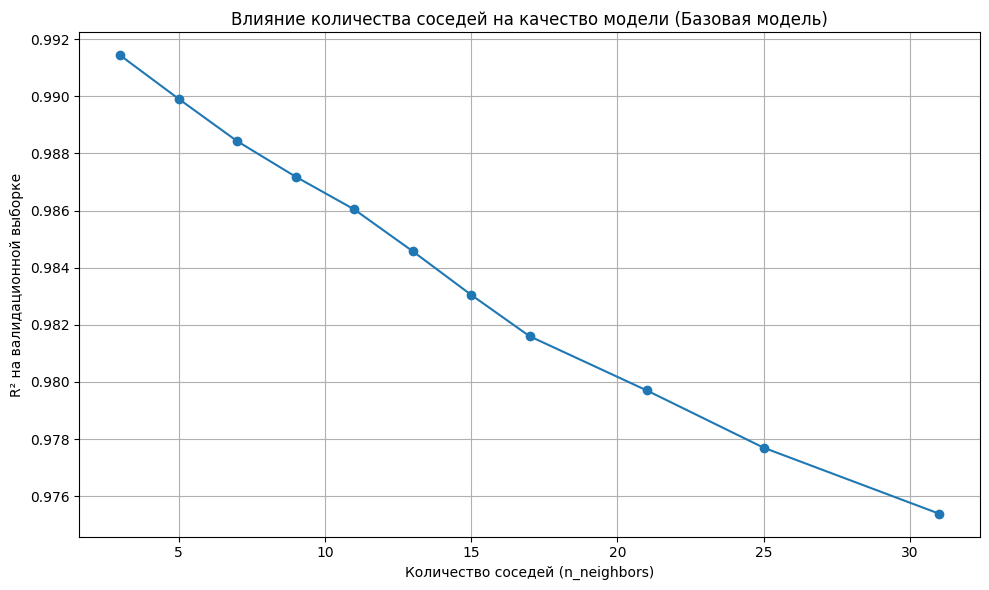

In [53]:
# Визуализируем влияние n_neighbors на R²
plt.figure(figsize=(10, 6))
plt.plot(n_neighbors_list, val_r2_scores, 'o-')
plt.xlabel('Количество соседей (n_neighbors)')
plt.ylabel('R² на валидационной выборке')
plt.title(f'Влияние количества соседей на качество модели ({best_model_name})')
plt.grid(True)
plt.tight_layout()
plt.show()



Выводы:
1. Лучшая модель: Базовая модель
2. Лучший R² на валидационной выборке: 0.9899
3. Улучшение по сравнению с базовой моделью: 0.0000
4. Оптимальное количество соседей: 3